# **HANDS - ON: EXPLORACIÓN DE DATOS**



Una vez visto la presentación ***Exploración de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1hX8uxJp5h03eYrgAnyznp8yeeG2syiD_/view?usp=drive_link)

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1eXIB1nd8aaBZWDYBXlIlfCOVkAe-ETrI?usp=drive_link).

## **ANÁLISIS EXPLORATPRIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importar datos
df_yt = pd.read_csv('youtube_clean.csv')
df_yt.head(10)

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
5,6,título,películas,42160,10721,3547,9033,58,2025-08-27
6,7,título,música,90723,6461,2057,5150,219,2021-05-04
7,8,título,comedia,166255,10284,300408,7206,115,2019-10-15
8,9,título,sin categoría,94776,19339,1855,2847,207,2017-07-18
9,10,título,música,129257,17151,458,9632,164,2023-08-26


In [23]:
print(f"Número de registros con views = 129257: {df_yt[df_yt['views'] == 129257].shape[0] / 308} %")

Número de registros con views = 129257: 0.13636363636363635 %


In [22]:
# Ver resumen estadístico de las columnas numéricas
columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
df_yt[columnas_numericas].describe()

,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

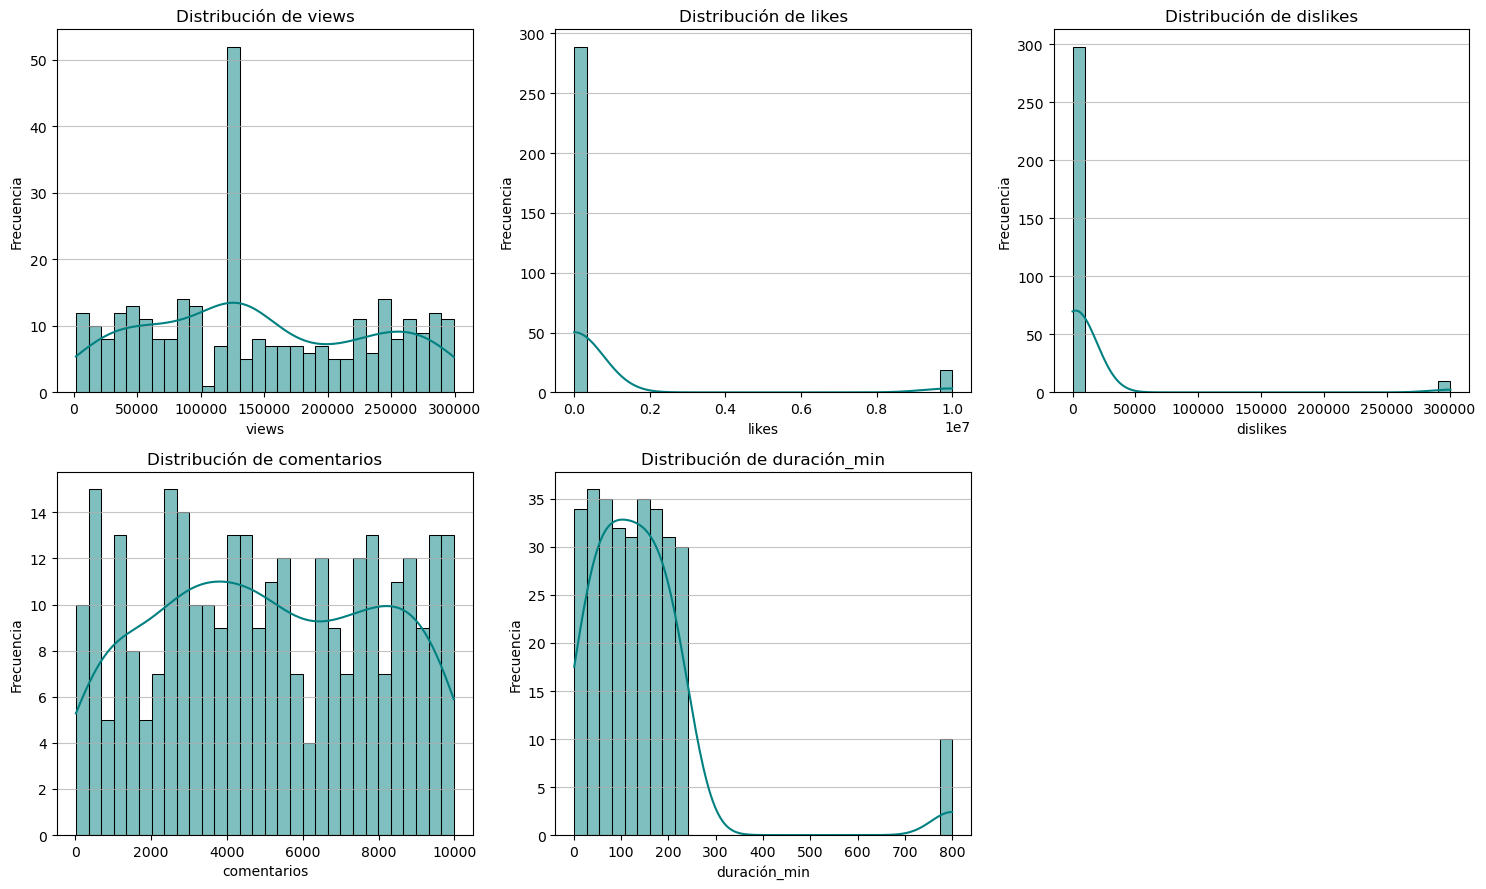

In [24]:
# Observar distribución de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.histplot(df_yt[col], kde=True, bins= 30, color = 'teal')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.title(f'Distribución de {col}')
  plt.grid(axis= 'y', alpha = 0.75 )

plt.tight_layout()
plt.show()

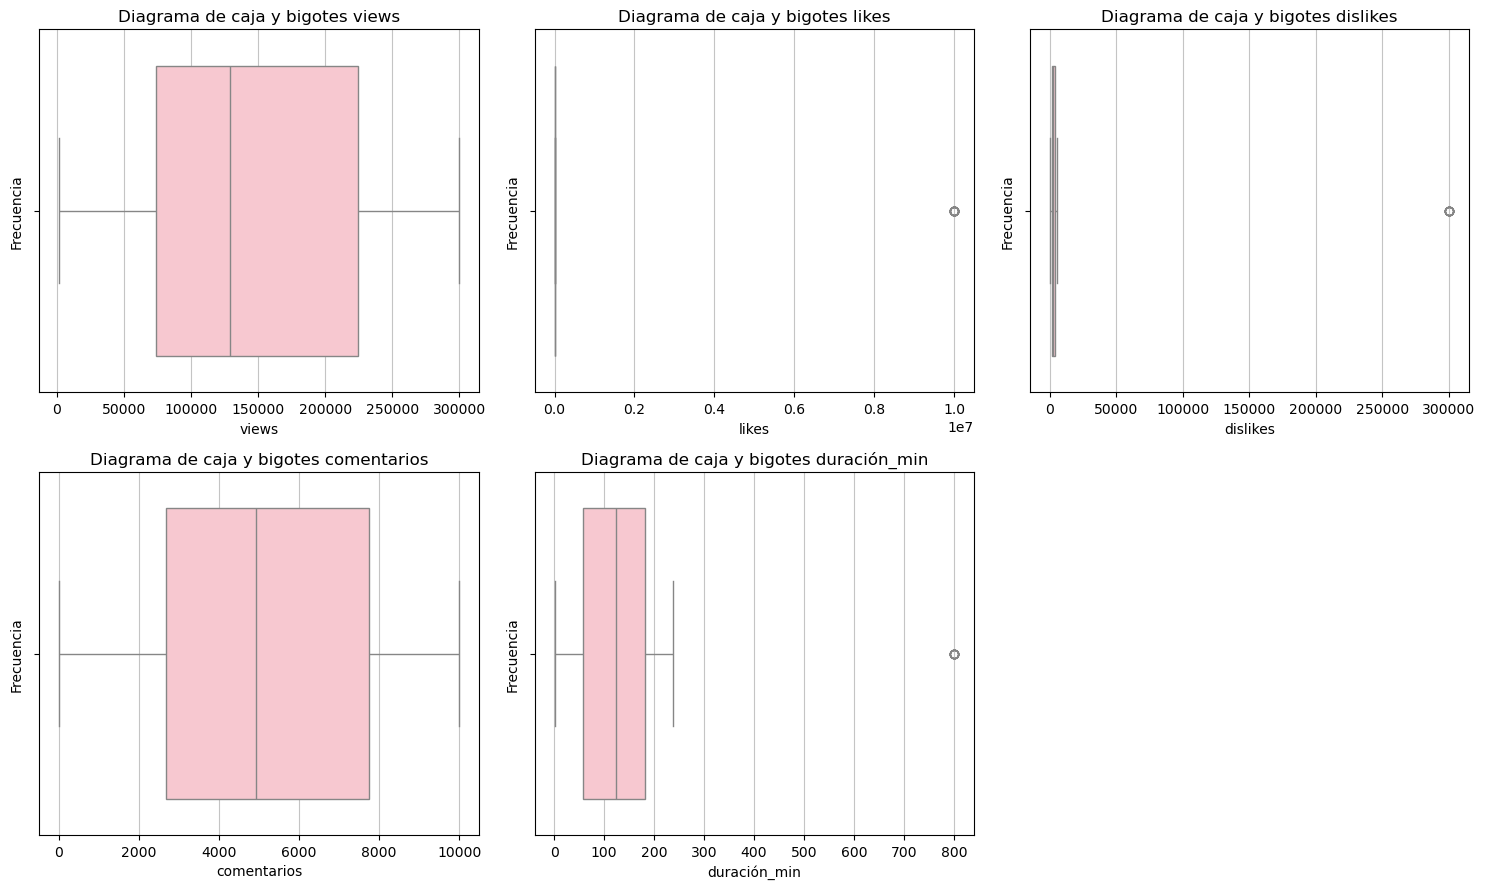

In [25]:
# Observar comportamiento cuartil de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.boxplot(x=df_yt[col], color = 'pink')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.title(f'Diagrama de caja y bigotes {col}')
  plt.grid(axis= 'x', alpha = 0.75 )

plt.tight_layout()
plt.show()

#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [27]:
# Ver cantidad de registros iniciales
print(f'Cantidad de datos iniciales: {len(df_yt)}')

Cantidad de datos iniciales: 308


In [28]:
# Calculo del IQR
df_copy = df_yt.copy()

for col in columnas_numericas:
  Q1 = df_copy[col].quantile(0.25)
  Q3 = df_copy[col].quantile(0.75)
  IQR = Q3 - Q1

  lim_inf_iqr = Q1 - 1.5 * IQR
  lim_sup_iqr = Q3 + 1.5 * IQR  #1.5 es el factor común para determinar los límites de los outliers

  cant_inicial = len(df_copy)
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)
  print(f'Cantidad de datos con outliers eliminados en {col}: {cant_inicial - cant_final}')

Cantidad de datos con outliers eliminados en views: 0
Cantidad de datos con outliers eliminados en likes: 19
Cantidad de datos con outliers eliminados en dislikes: 10
Cantidad de datos con outliers eliminados en comentarios: 0
Cantidad de datos con outliers eliminados en duración_min: 10


In [29]:
# Ver cantidad de registros finales y proporción con la cantidad inicial
prop_cant_datos= round((len(df_copy) / len(df_yt)) * 100, 2)
print(f'Cantidad de datos finales: {len(df_copy)}')
print(f'Proporción de datos eliminados: {prop_cant_datos}%') #¿por qué no se resto -100


Cantidad de datos finales: 269
Proporción de datos eliminados: 87.34%


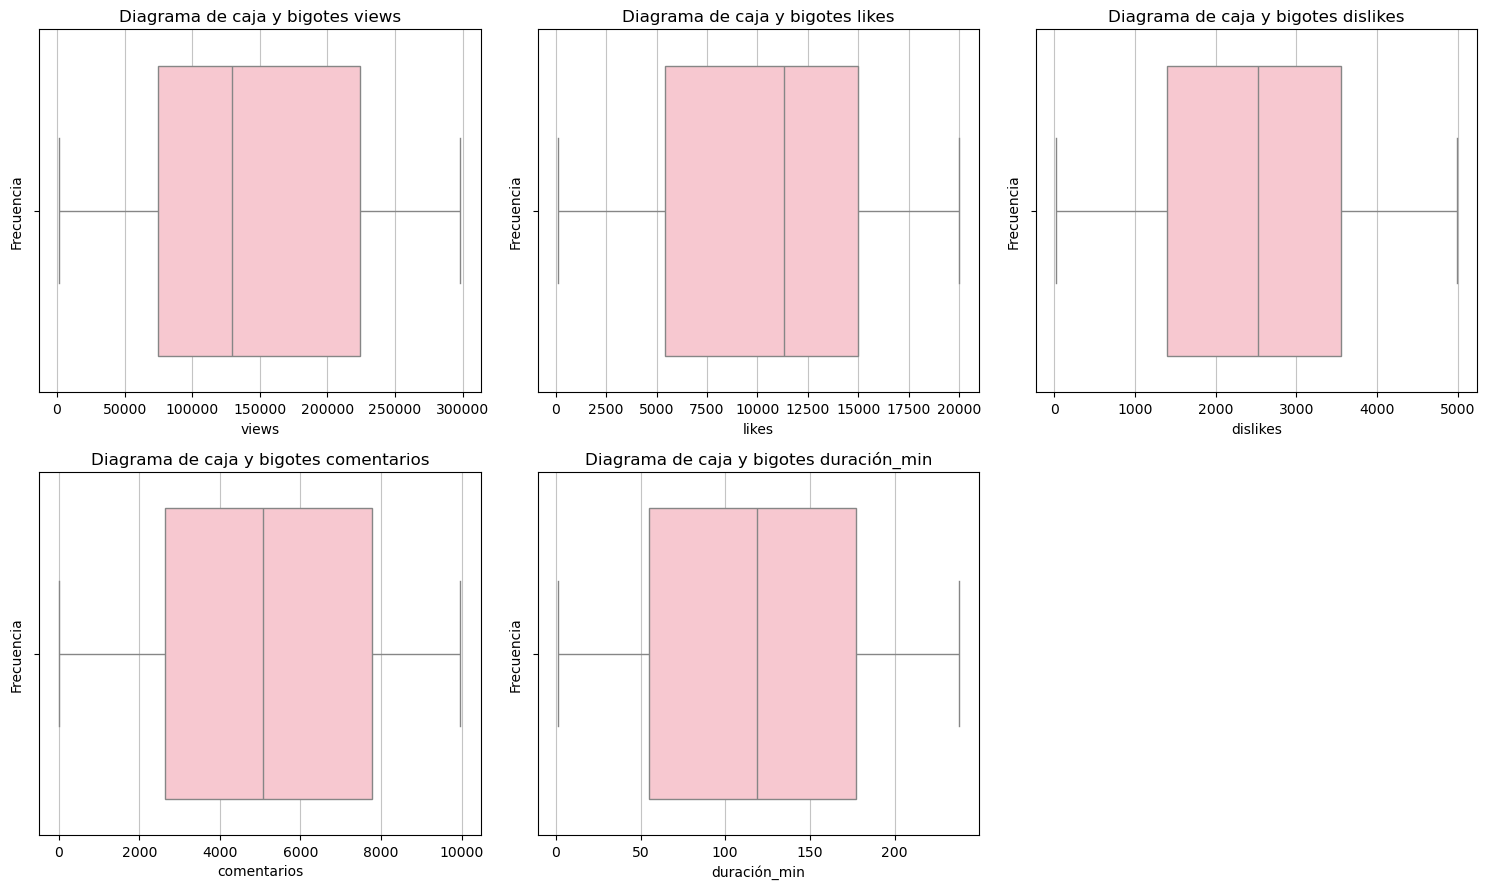

In [30]:
# Observar comportamiento cuartil final de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.boxplot(x=df_copy[col], color = 'pink')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.title(f'Diagrama de caja y bigotes {col}')
  plt.grid(axis= 'x', alpha = 0.75 )

plt.tight_layout()
plt.show()

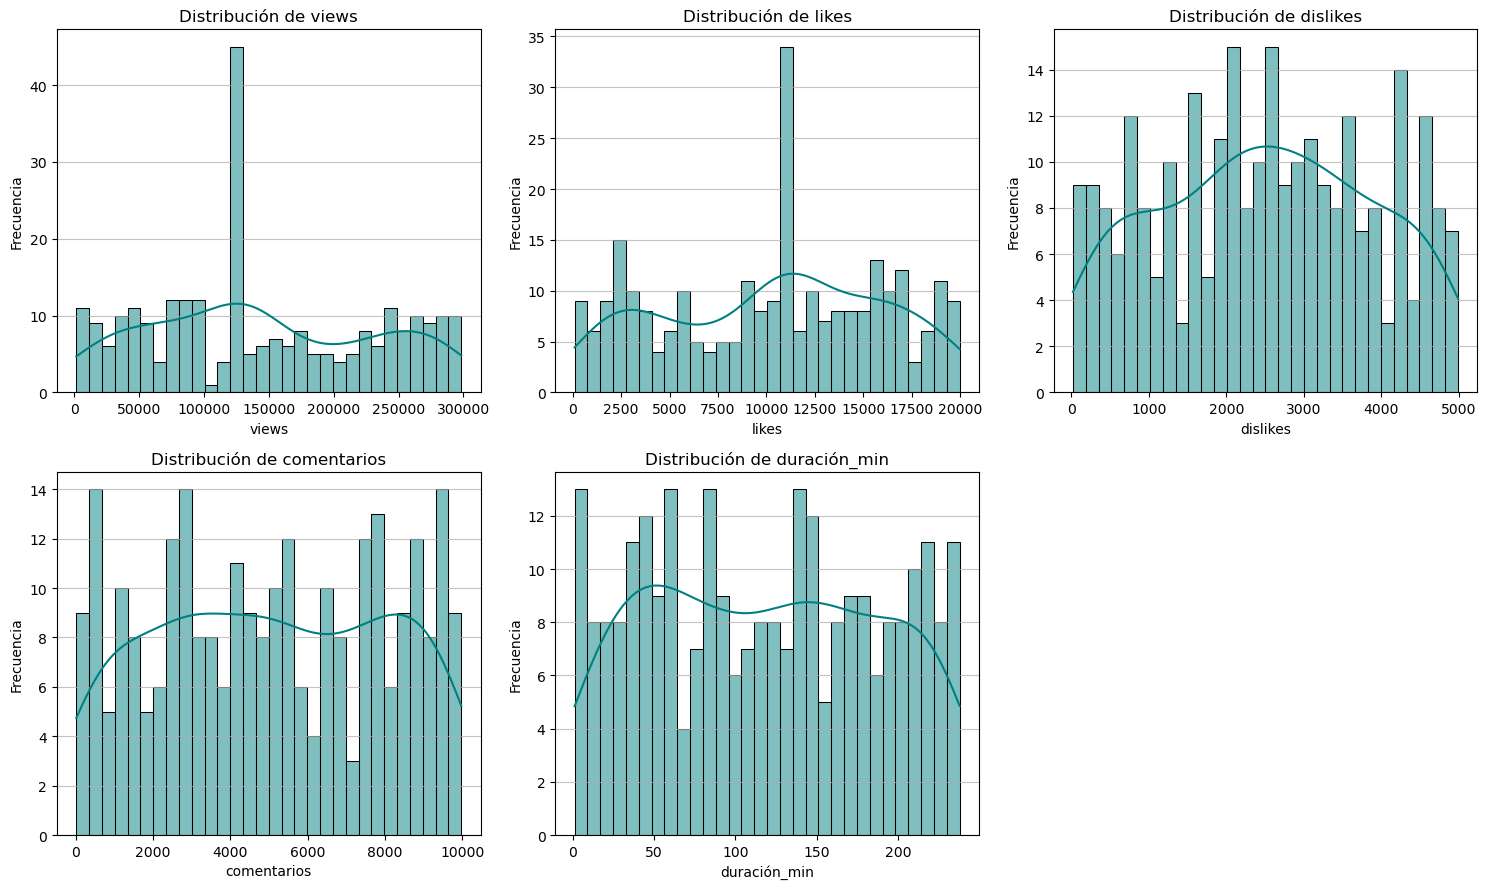

In [31]:
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.histplot(df_copy[col], kde=True, bins= 30, color = 'teal')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.title(f'Distribución de {col}')
  plt.grid(axis= 'y', alpha = 0.75 )

plt.tight_layout()
plt.show()

### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

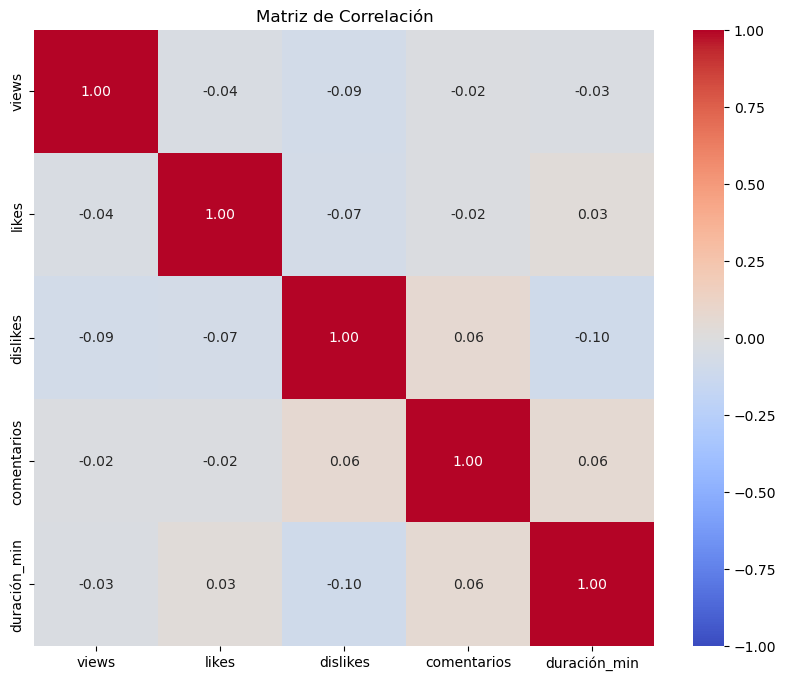

In [32]:
# Realizar matriz de correlación
corr_matrix = df_copy[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()


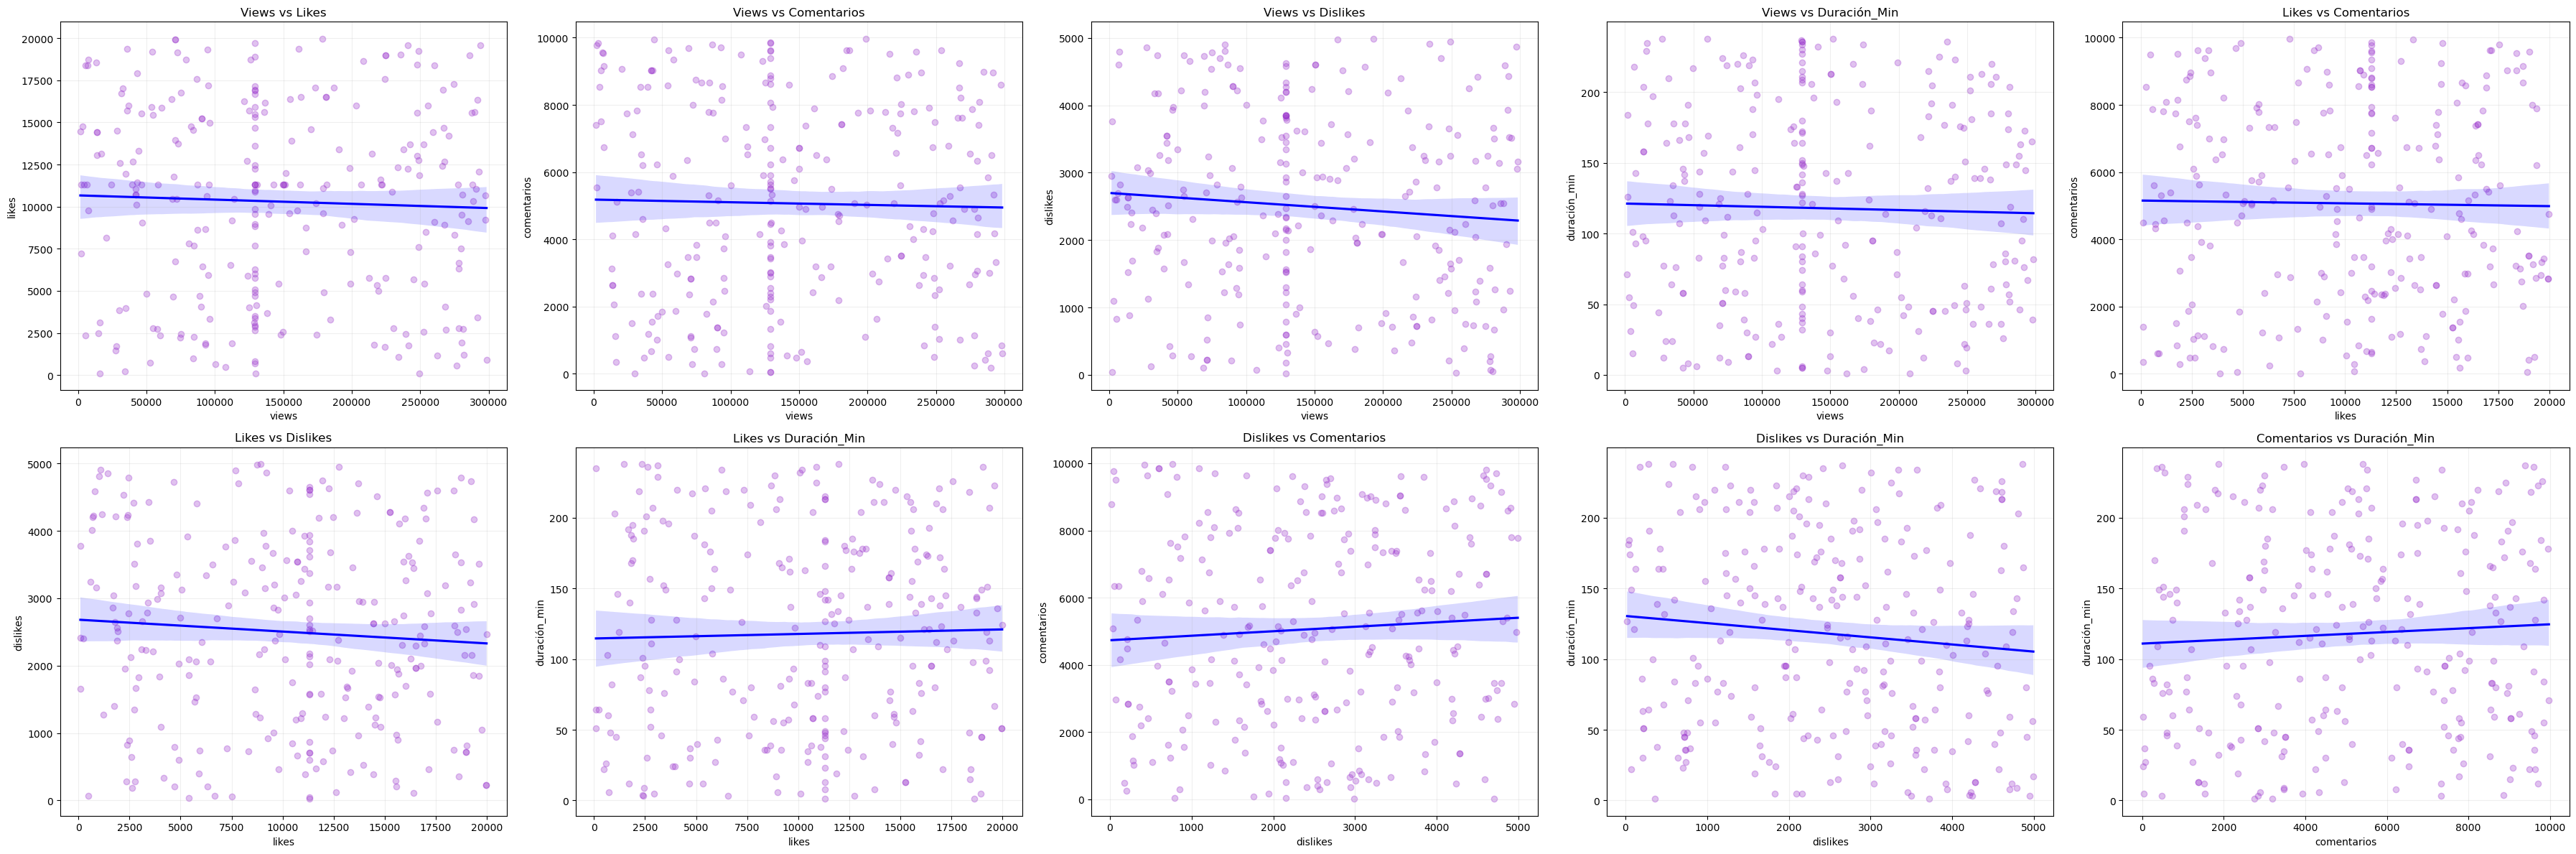

In [33]:
# Realizar correlaciones divididas

metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por
comparaciones = [
    ('views', 'likes'), ('views', 'comentarios'), ('views', 'dislikes'),
    ('views', 'duración_min'), ('likes', 'comentarios'), ('likes', 'dislikes'),
    ('likes', 'duración_min'), ('dislikes', 'comentarios'),
    ('dislikes', 'duración_min'), ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'blue'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

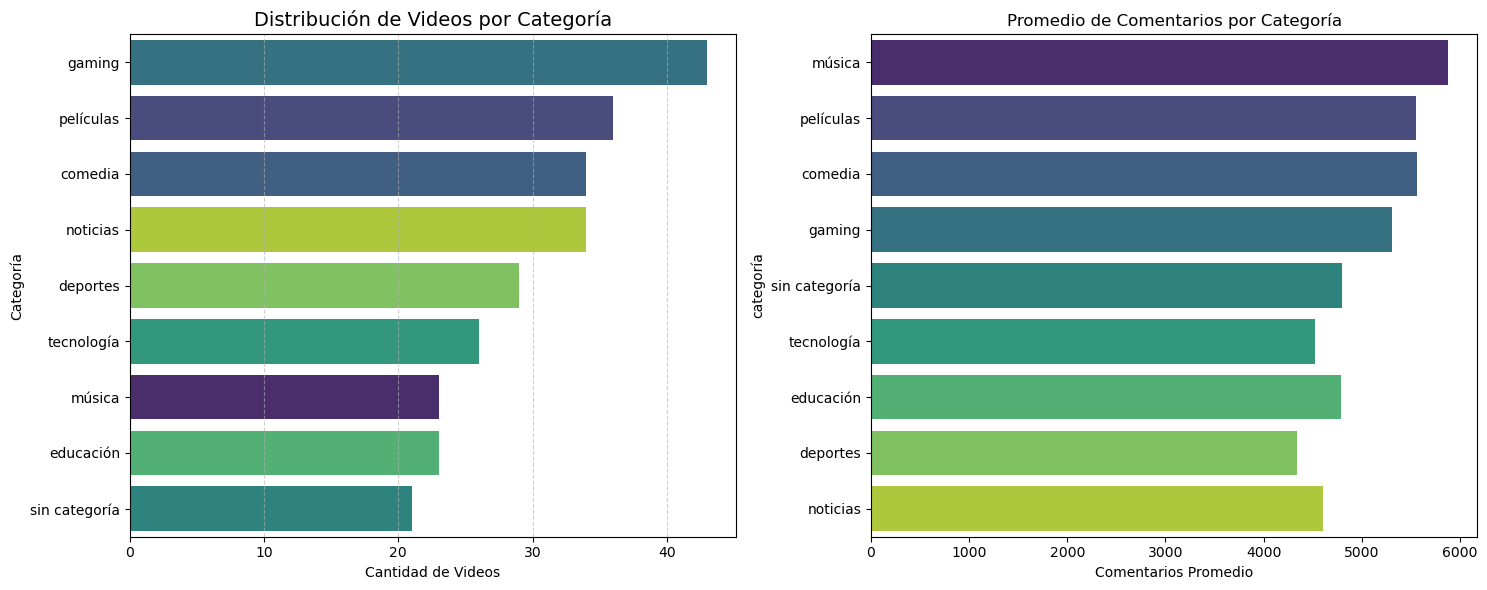

In [35]:
# Realizar gráficos de barras divididas
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()

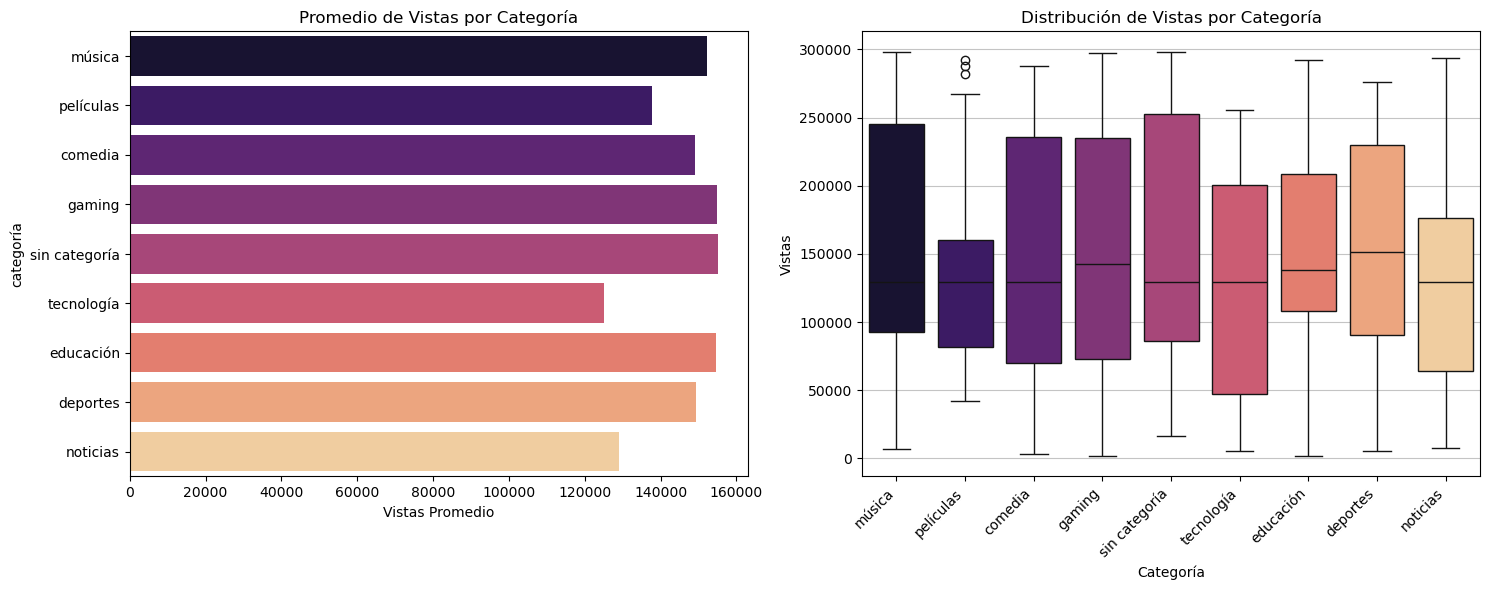

In [36]:
# Realizar gráfico de barras y caja divididos
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [37]:
# Definir variables para la agrupación
categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_yt['agrupación_cat'] = df_yt['categoría'].apply(categoria)
pie_data = df_yt['agrupación_cat'].value_counts()
pie_data

agrupación_cat
Con Categoría    283
Sin Categoría     25
Name: count, dtype: int64

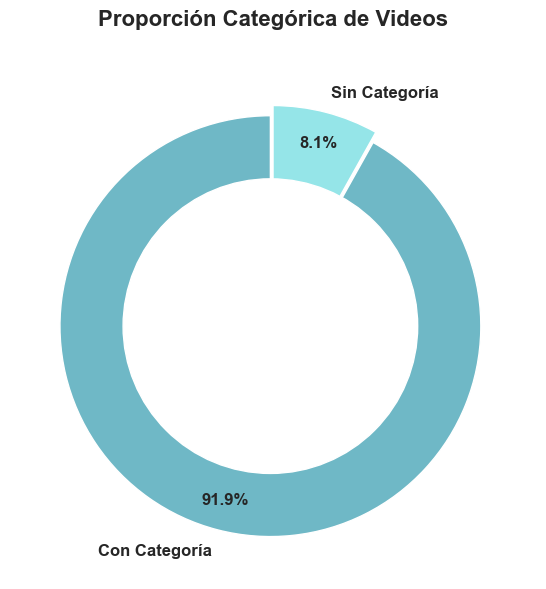

In [42]:
# Realizar gráfico de dona
colors_pie = ['#00829B90', '#2DCCD380'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [39]:
# Definir variables
df_filtrado = df_yt[df_yt['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

In [51]:
counts

categoría
gaming        50
películas     44
comedia       37
noticias      37
deportes      32
tecnología    31
música        28
educación     24
Name: count, dtype: int64

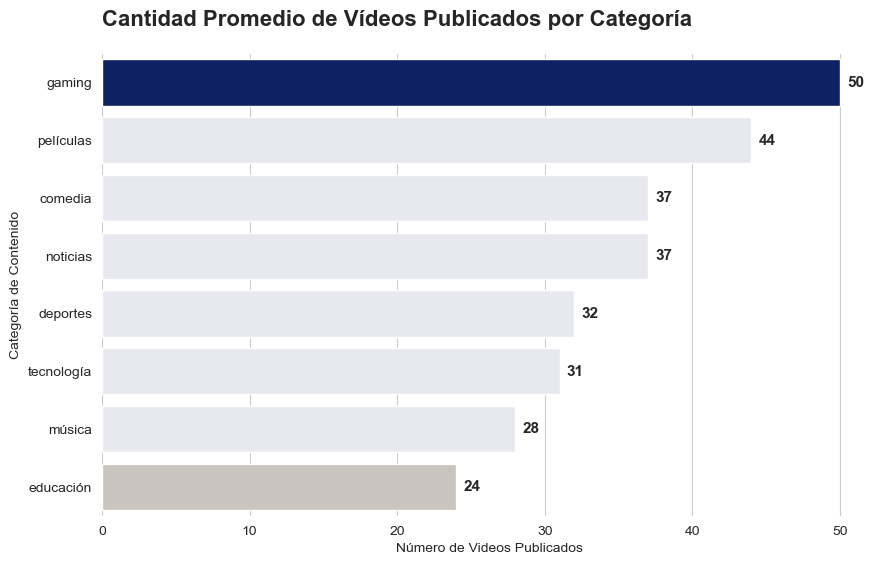

In [40]:
# Realizar gráfico de barras
colors = ['#001A70' if v == values.max() else '#CBC4BC' if v == values.min() else '#E6E8F0' for v in values]
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [49]:
# Definir variables
vistas_mean = df_yt.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]

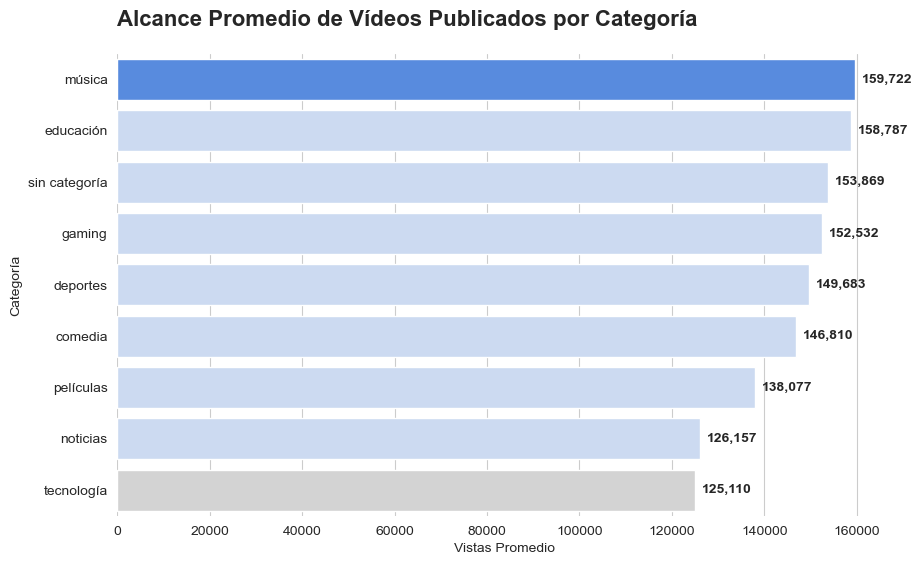

In [50]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [52]:
# Definir variables
coments_mean = df_yt.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]

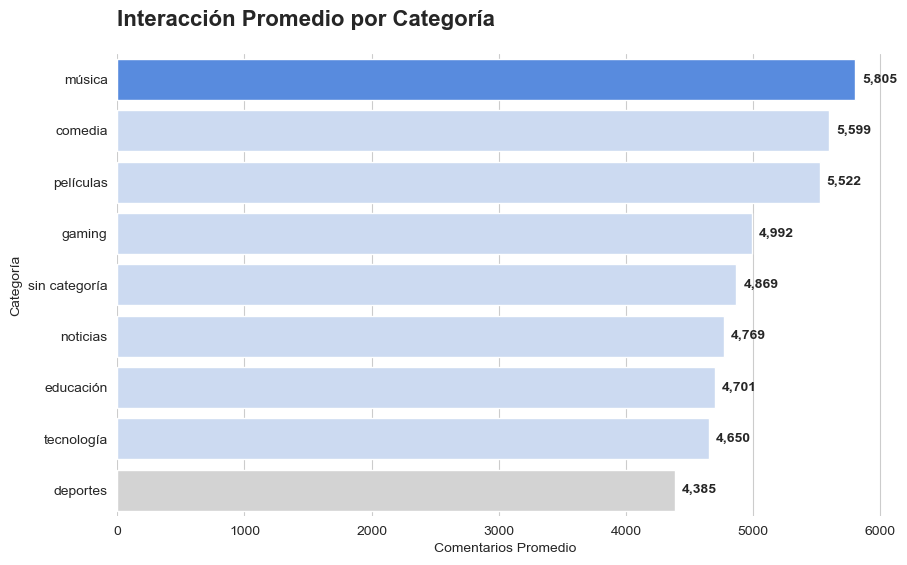

In [53]:
# Realizar gráfico de barras
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

## **CHALLENGE: EXPLORACIÓN DE DATOS AIRBNB CDMX**

Una vez visto el ***Hands - On: Exploración de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1HKCV2jFnumpJ1YNFI5cn6wgT2tEiKKfK/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un análisis exploratorio profundo sobre el catálogo de alojamientos de Airbnb en la Ciudad de México** para detectar patrones de comportamiento, valores atípicos y relaciones entre variables. Se hará uso de **herramientas estadísticas, técnicas de detección de outliers y narrativa visual** a través del dataset **"airbnb_clean"**.

Donde los análisis a realizar son:

* **Detección y tratamiento de valores atípicos mediante el rango intercuartílico**.
* **Identificación de relaciones lineales entre variables numéricas**.
* **Comunicación de hallazgos a través de narrativa visual por categoría**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y análisis de resumen estadístico:**

* Carga las bibliotecas de Pandas, Numpy, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_clean.csv*.
* Obtén el resumen estadístico de los datos.

In [54]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [56]:
# Importar datos
df_airbnb =pd.read_csv('airbnb_clean.csv')
df_airbnb.head(10)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,35797,Villa Dante,153786,Dici,Cuajimalpa de Morelos,19.38283,-99.27178,Entire home/apt,3673.0,1,0,Never reviewed,0.00,1,363,0
1,44616,Condesa Haus,196253,Fernando,Cuauhtémoc,19.41162,-99.17794,Entire home/apt,18000.0,1,65,2025-01-01,0.38,9,360,1
2,56074,Great space in historical San Rafael,265650,Maris,Cuauhtémoc,19.43977,-99.15605,Entire home/apt,591.0,15,84,2025-02-27,0.48,1,333,1
3,67703,"2 bedroom apt. deco bldg, Condesa",334451,Nicholas,Cuauhtémoc,19.41152,-99.16857,Entire home/apt,1039.0,2,50,2024-10-30,0.30,2,252,1
4,70644,Beautiful light Studio Coyoacan- full equipped !,212109,Trisha,Coyoacán,19.35448,-99.16217,Entire home/apt,1039.0,3,134,2025-08-18,0.81,3,234,8
5,131610,MARIA DEL ALMA,647454,Fernando,Coyoacán,19.35416,-99.16488,Private room,1039.0,1,0,Never reviewed,0.00,3,0,0
6,165772,BEST 5 Bedroom HOUSE IN S. Miguel Chapultepec,790208,Francisco Carlos,Miguel Hidalgo,19.40826,-99.18659,Entire home/apt,3673.0,2,386,2025-08-10,2.24,5,201,28
7,171109,Cool room near WTC and Metrobus,816295,Carlos,Benito Juárez,19.39675,-99.17581,Private room,321.0,4,123,2025-09-07,0.88,2,301,15
8,180808,"Huge Luxurious Suite 70's style, perfectly loc...",36836,Roberto,Cuauhtémoc,19.42390,-99.16890,Entire home/apt,1190.0,3,62,2025-09-01,0.38,1,315,10
9,187030,Spacious apt with the best rooftop in Condesa,899360,Julian,Cuauhtémoc,19.41057,-99.17730,Entire home/apt,1039.0,4,103,2023-09-08,0.61,6,0,0


In [60]:
# Ver resumen estadístico

columnas_numericas_airbnb = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
df_airbnb[columnas_numericas_airbnb].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000
mean,1695.489483,4.580866,53.777679,1.621652,232.686333
std,12352.097771,24.784605,85.143043,2.219818,122.270858
min,61.000000,1.000000,0.000000,0.000000,0.000000
25%,700.000000,1.000000,4.000000,0.210000,140.000000
50%,1039.000000,2.000000,21.000000,1.000000,269.000000
75%,1484.000000,2.000000,69.000000,2.370000,341.000000
max,900000.000000,1125.000000,1434.000000,119.460000,365.000000


**2. Análisis de distribución y filtrado de outliers:**

* Genera un histograma y diagrama de caja sobre la columna `price`.
* Calcula la cantidad de registros con los que cuenta el dataframe.
* Calcula el rango intercuartílico y filtra el dataframe con los registros dentro de los límites.
* Calcula la cantidad y proporción de registros finales y grafica su diagrama de caja.

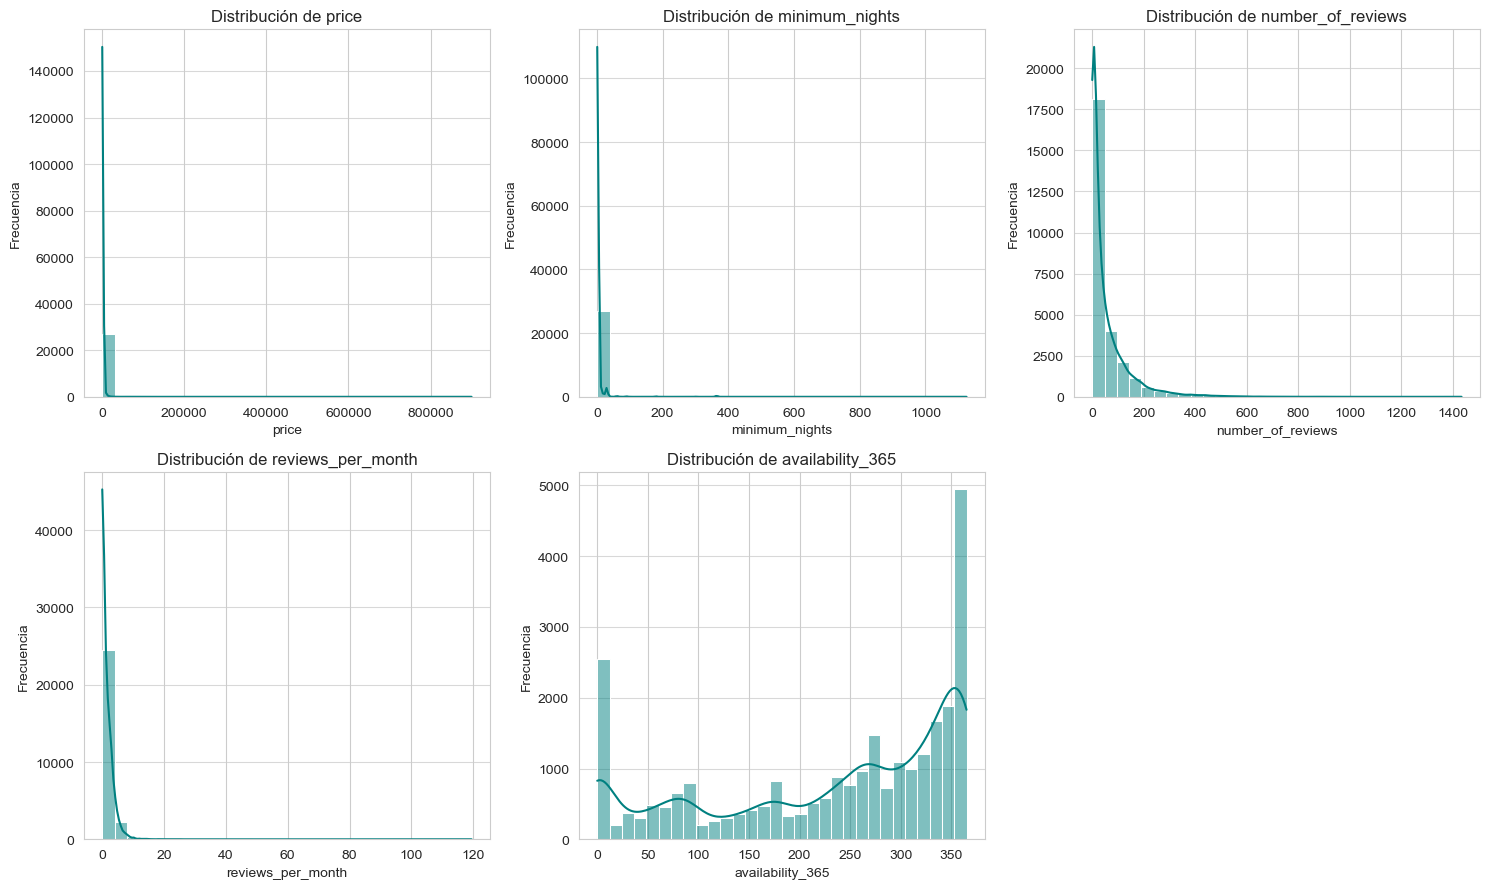

In [63]:
# Observar distribución y comportamiento cuartil de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas_airbnb, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_airbnb[col], kde=True, bins=30, color='teal')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {col}')
    plt.grid(axis= 'y', alpha = 0.75 )

plt.tight_layout()
plt.show()



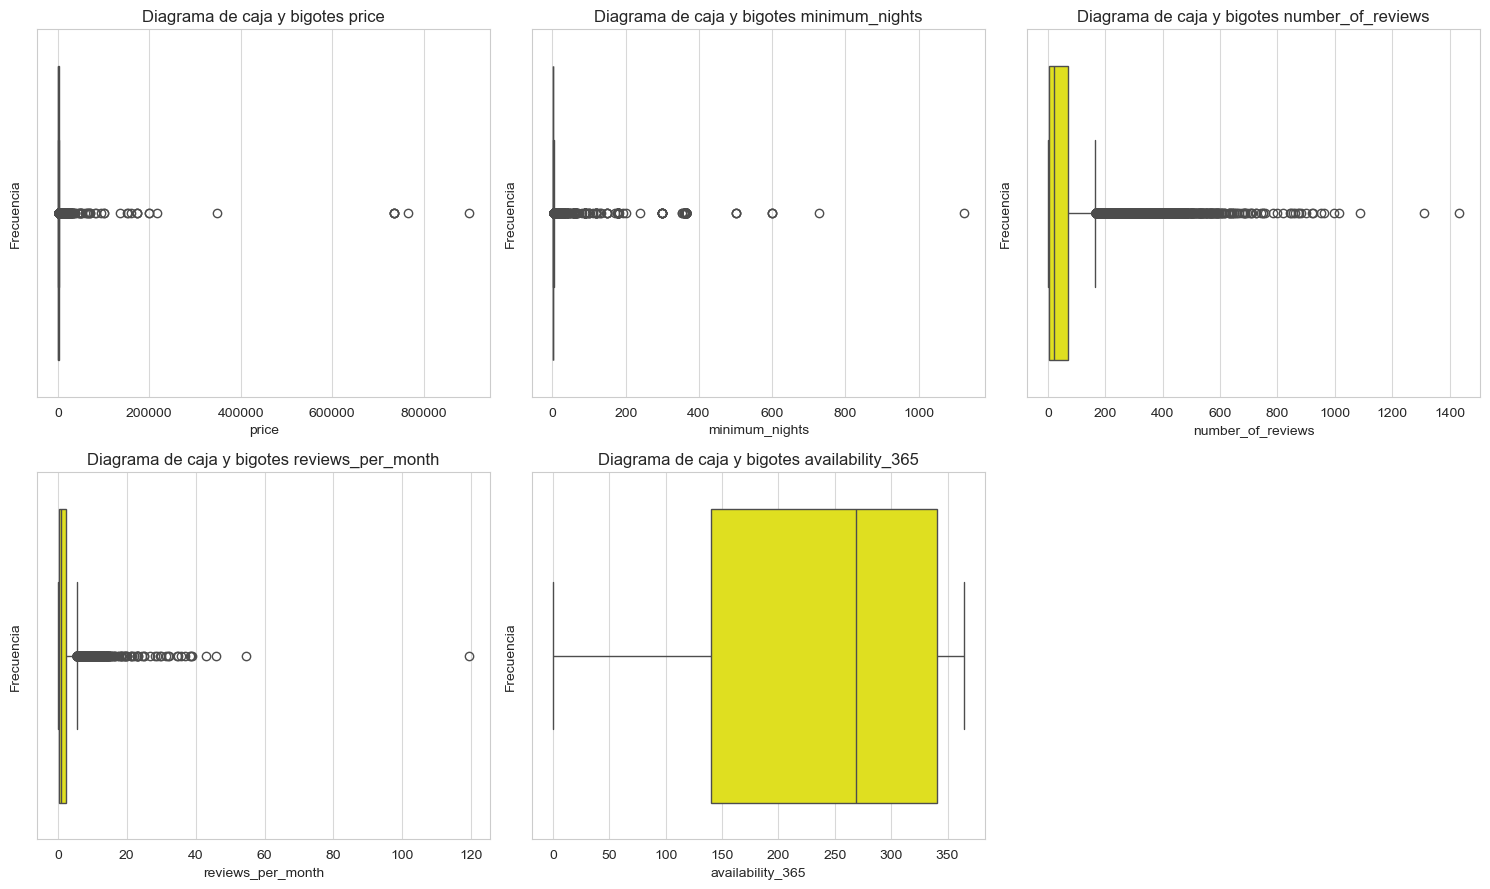

In [74]:

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas_airbnb, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.boxplot(x=df_airbnb[col], color = 'yellow')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.title(f'Diagrama de caja y bigotes {col}')
  plt.grid(axis= 'x', alpha = 0.75 )

plt.tight_layout()
plt.show()

In [64]:
# Ver cantidad de registros iniciales
print(f'Cantidad de datos iniciales: {len(df_airbnb)}')


Cantidad de datos iniciales: 27051


In [66]:
# Calculo del IQR
df_copy = df_airbnb.copy()

for col in columnas_numericas_airbnb:
  Q1 = df_copy[col].quantile(0.25)
  Q3 = df_copy[col].quantile(0.75)
  IQR = Q3 - Q1

  lim_inf_iqr = Q1 - 1.5 * IQR
  lim_sup_iqr = Q3 + 1.5 * IQR

  cant_inicial = len(df_copy)
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)
  print(f'Cantidad de datos con outliers eliminados en {col}: {cant_inicial - cant_final}')

Cantidad de datos con outliers eliminados en price: 2310
Cantidad de datos con outliers eliminados en minimum_nights: 3199
Cantidad de datos con outliers eliminados en number_of_reviews: 1642
Cantidad de datos con outliers eliminados en reviews_per_month: 731
Cantidad de datos con outliers eliminados en availability_365: 0


In [67]:
# Ver cantidad y proporción con la cantidad inicial

prop_cant_datos= round((len(df_copy) / len(df_airbnb)) * 100, 2)
print(f'Cantidad de datos finales: {len(df_copy)}')
print(f'Proporción de datos eliminados: {prop_cant_datos}%') #¿por qué no se resto -100

Cantidad de datos finales: 19169
Proporción de datos eliminados: 70.86%


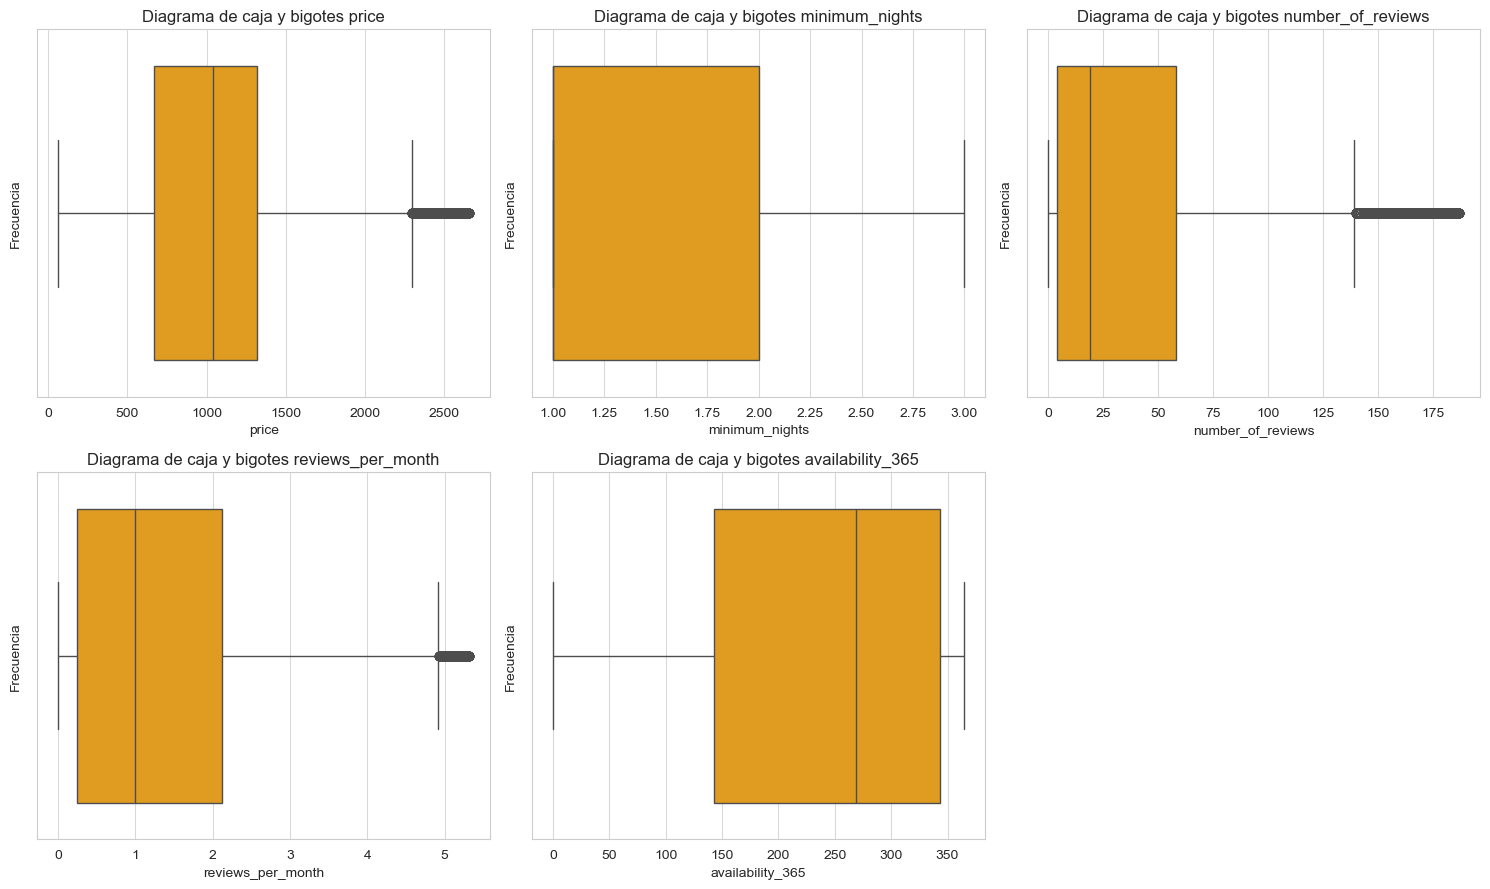

In [76]:
# Observar comportamiento cuartil final de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas_airbnb, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.boxplot(x=df_copy[col], color = 'orange')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.title(f'Diagrama de caja y bigotes {col}')
  plt.grid(axis= 'x', alpha = 0.75 )

plt.tight_layout()
plt.show()

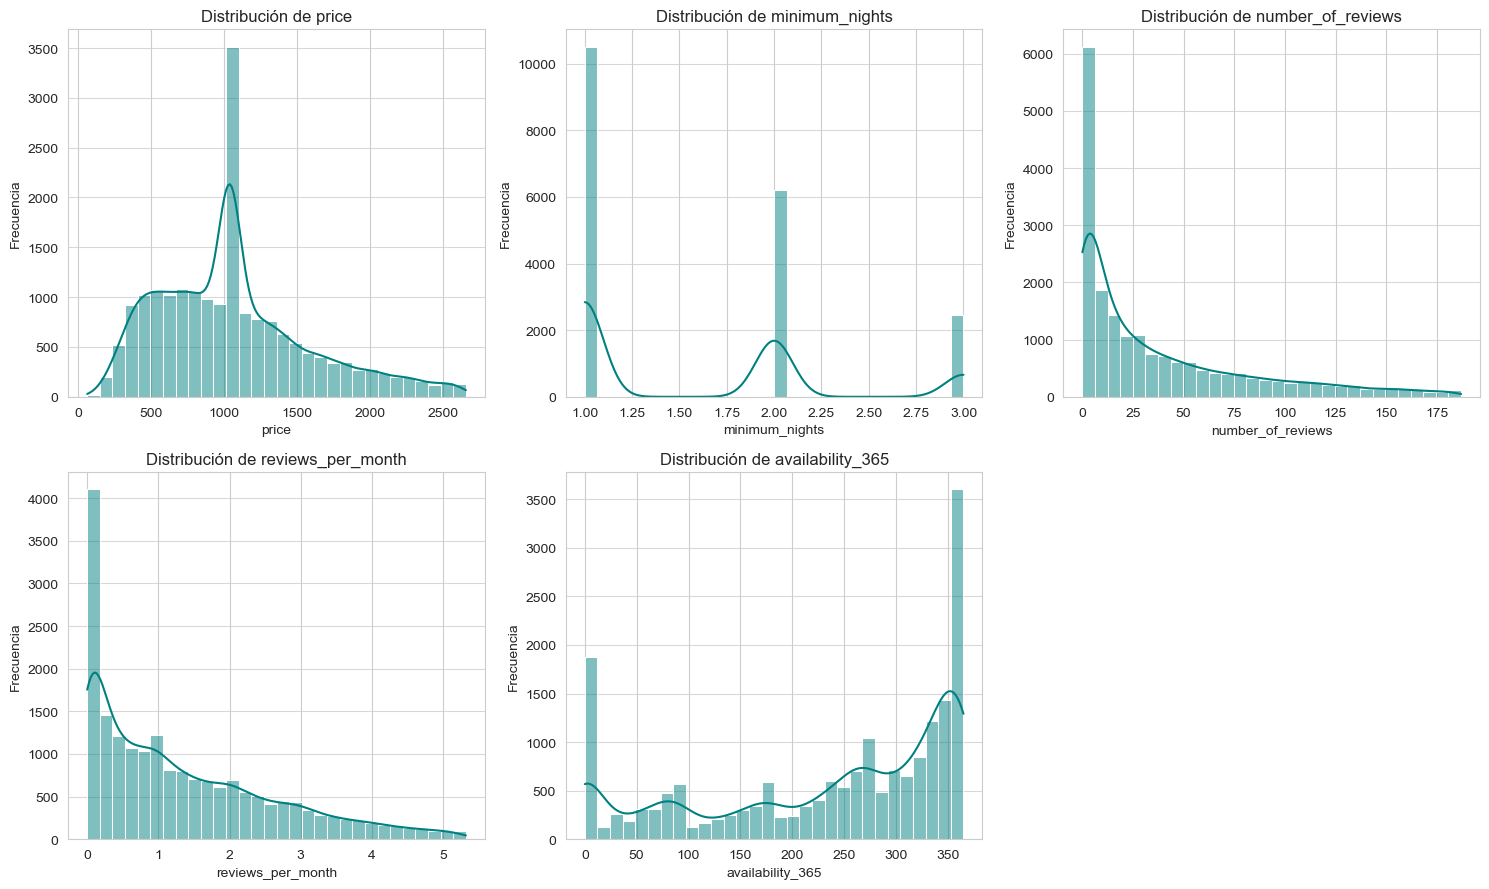

In [78]:
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas_airbnb, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_copy[col], kde=True, bins=30, color='teal')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {col}')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()
 

**3. Análisis de correlaciones:**

* Genera una matriz de correlación sobre las columnas numéricas del dataframe.
* Selecciona las variables numéricas más representativas.
* Realiza correlaciones divididas por categoría segmentadas por la columna `room_type`.

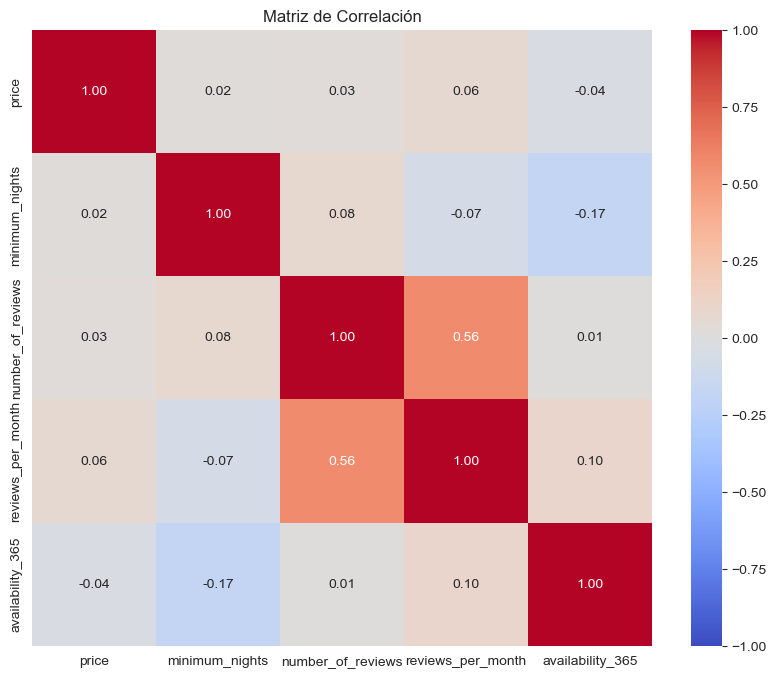

In [80]:
# Realizar matriz de correlación
corr_matrix = df_copy[columnas_numericas_airbnb].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

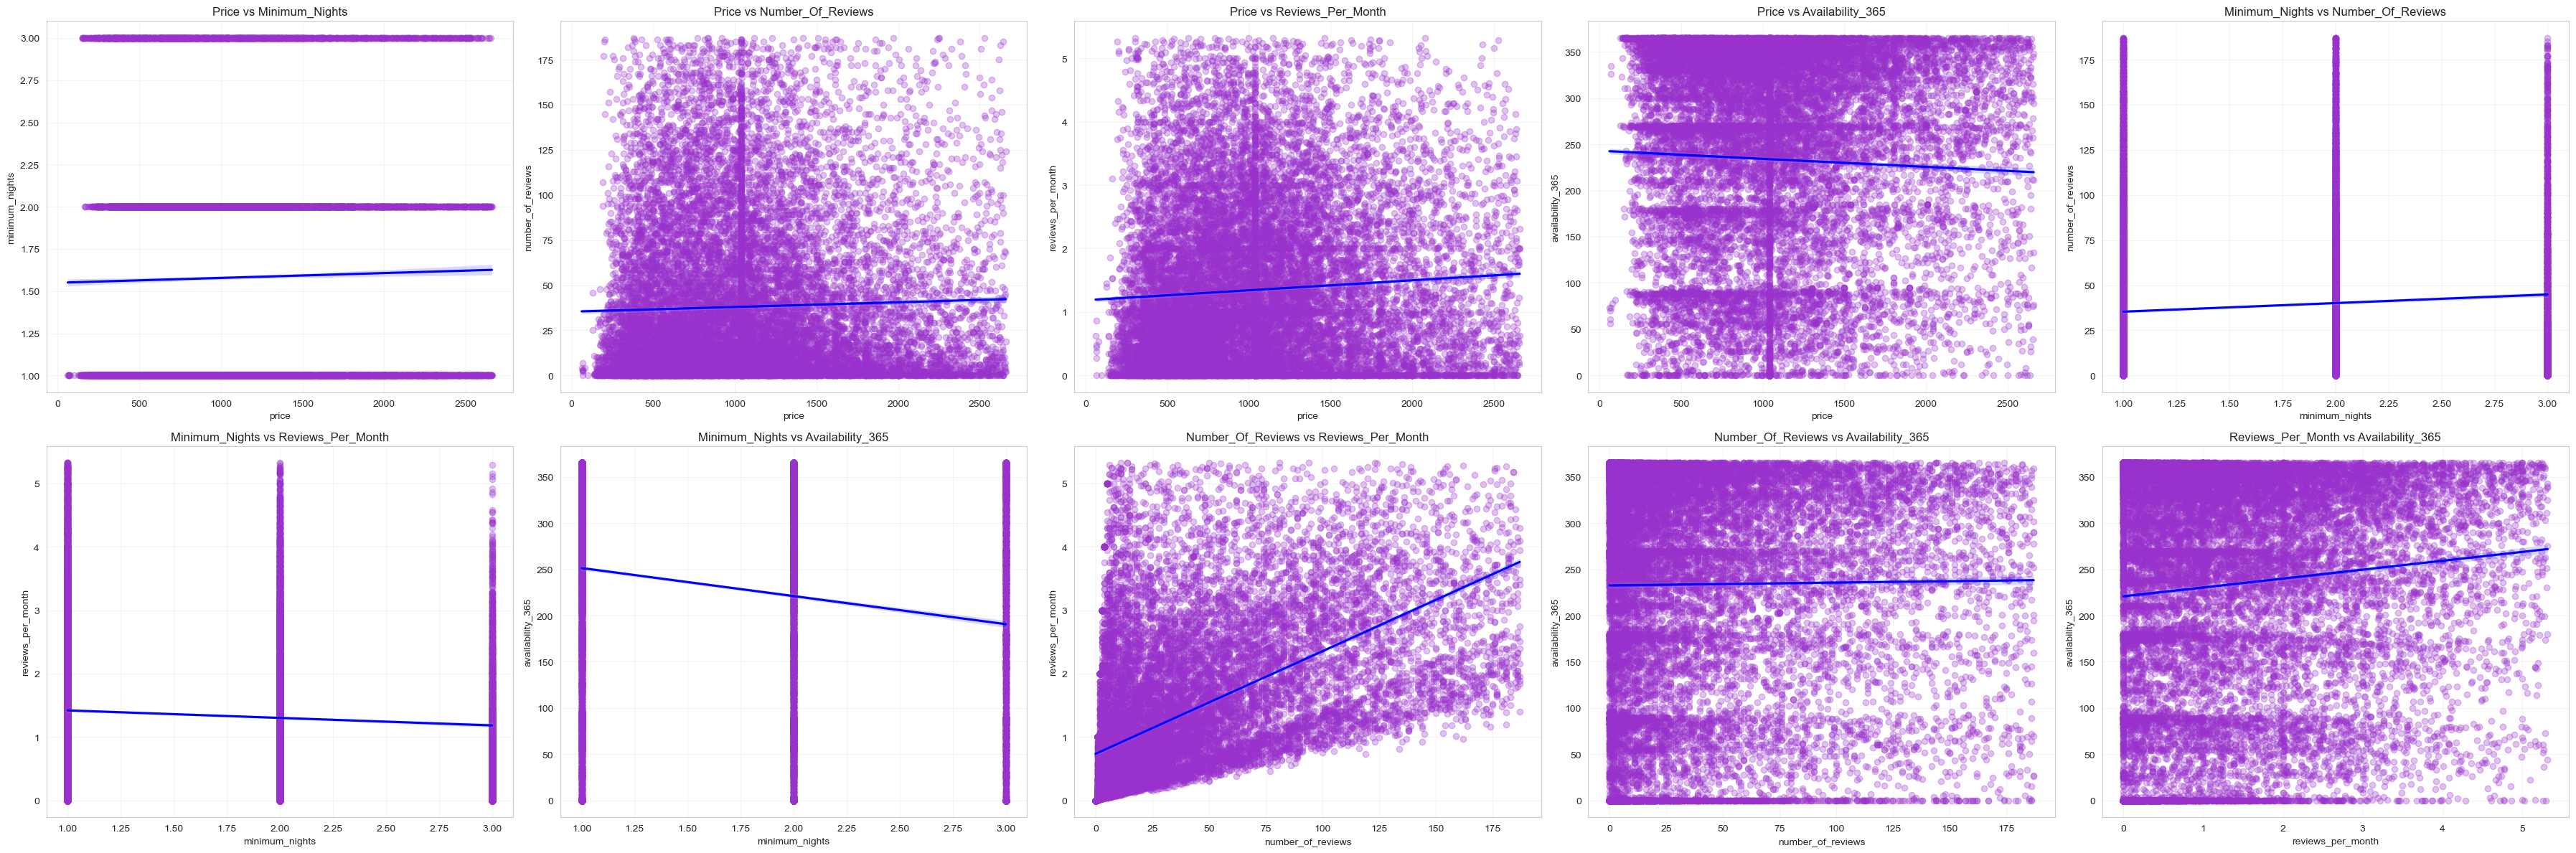

In [82]:
# Realizar correlaciones divididas
metricas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por
comparaciones = [
    ('price', 'minimum_nights'), ('price', 'number_of_reviews'), ('price', 'reviews_per_month'),
    ('price', 'availability_365'), ('minimum_nights', 'number_of_reviews'), ('minimum_nights', 'reviews_per_month'),
    ('minimum_nights', 'availability_365'), ('number_of_reviews', 'reviews_per_month'),
    ('number_of_reviews', 'availability_365'), ('reviews_per_month', 'availability_365')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'blue'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**4. Regresión lineal simple:**

* Define como variable independiente `reviews_per_month` y como dependiente `number_of_reviews_ltm`.
* Calcula los coeficientes para determinar la ecuación del modelo de regresión lineal simple.
* Ajusta el modelo de regresión lineal con descenso de gradiente y determina la nueva ecuación.
* Visualizar el modelo de regresión lineal ajustada y la curva de perdidas.
* Calcula la reducción del error desde la primera hasta la última época.


In [83]:
# Cálculo de la regresión lineal simple
x = df_copy['reviews_per_month']
y = df_copy['number_of_reviews']

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta}x + {alpha}')

y = 19.565406672803967x + 11.648265157790656


In [95]:
# Calculo del descenso de gradiente
tamano_paso = 0.001
theta_0 = 0
theta_1 = 0

perdida = []

In [96]:
num_iteraciones = 100

for i in range(num_iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y - y_pred) ** 2).mean()
  perdida.append(error)

  d_theta_0 = (2 / len(x)) * np.sum(y_pred - y)
  d_theta_1 = (2 / len(x)) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - tamano_paso * d_theta_0
  theta_1 = theta_1 - tamano_paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 11.458169025273794 x + 5.284328612539548


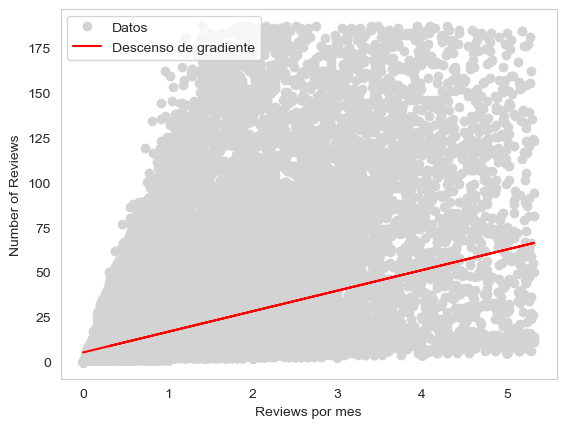

In [86]:
# Visualizar regresión lineal y perdidas
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Reviews por mes')
plt.ylabel('Number of Reviews')
plt.legend()
plt.grid()
plt.show()

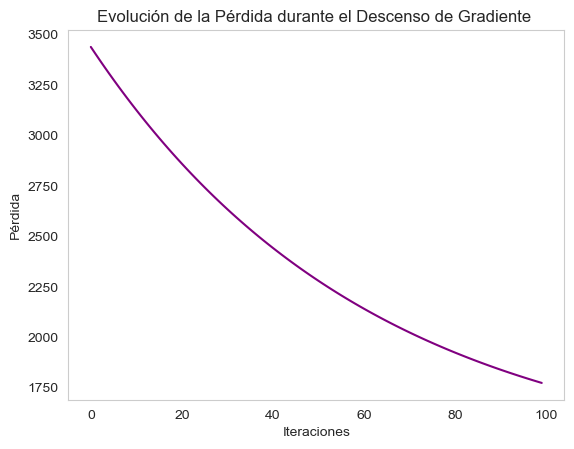

In [92]:
# Registro final de perdida

plt.plot(perdida, color = 'purple')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida durante el Descenso de Gradiente ')
plt.grid()
plt.show()

**5. Comparación por categoría:**

* Utiliza un gráfico de barras para mostrar el precio promedio por tipo de habitación.
* Utiliza un diagrama de caja para visualizar la distribución del precio por tipo de habitación.
* Agrupa el dataframe por la columna `room_type` y calcula el conteo de alojamientos.
* Utiliza un gráfico de dona que muestre el porcentaje de cada categoría.

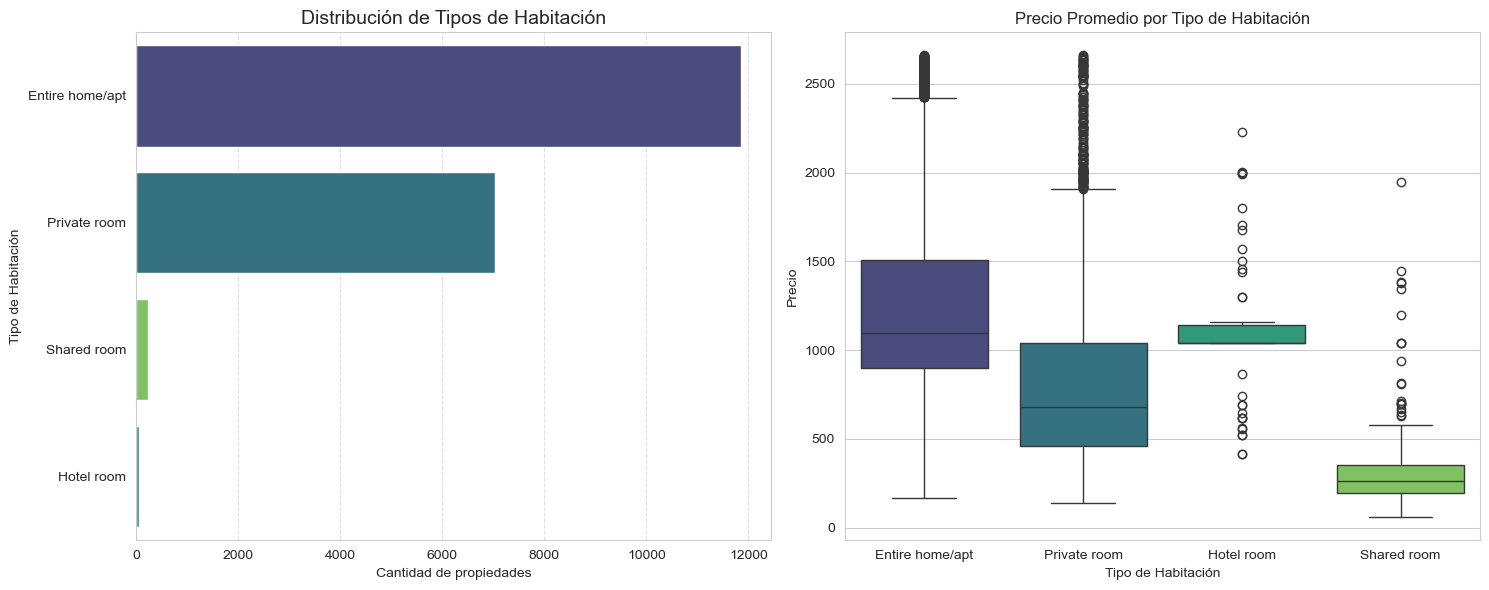

In [114]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['room_type'].value_counts().index
sns.countplot(data=df_copy, y='room_type', order=orden, palette='viridis', hue='room_type', legend=False)
plt.title('Distribución de Tipos de Habitación', fontsize=14)
plt.xlabel('Cantidad de propiedades')
plt.ylabel('Tipo de Habitación')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='room_type', y='price', palette='viridis', hue='room_type', legend=False)
plt.title('Precio Promedio por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio')

plt.tight_layout()
plt.show()

In [119]:
# Definir variables para la agrupación
categoria = lambda x: 'Alojamiento completo' if x == 'Entire home/apt' else 'Habitación compartida'

df_copy['agrupacion_room'] = df_copy['room_type'].apply(categoria)
pie_data = df_copy['agrupacion_room'].value_counts()
pie_data

agrupacion_room
Alojamiento completo     11849
Habitación compartida     7320
Name: count, dtype: int64

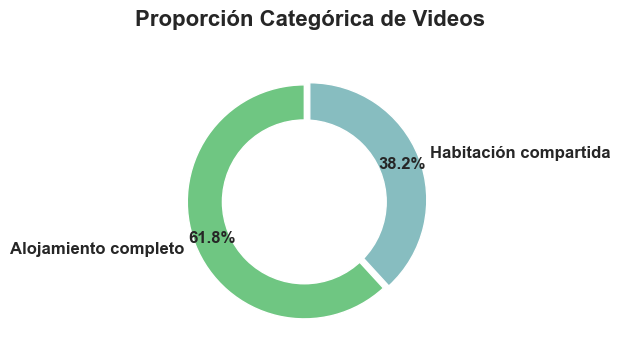

In [121]:
# Realizar gráfico de dona
colors_pie = ["#009B2290", "#117D8380"] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**6. Narrativa visual:**

* Utiliza un gráfico de barras horizontales para mostrar el conteo de alojamientos por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el promedio de reseñas por alcaldía.

<Figure size 1000x600 with 0 Axes>

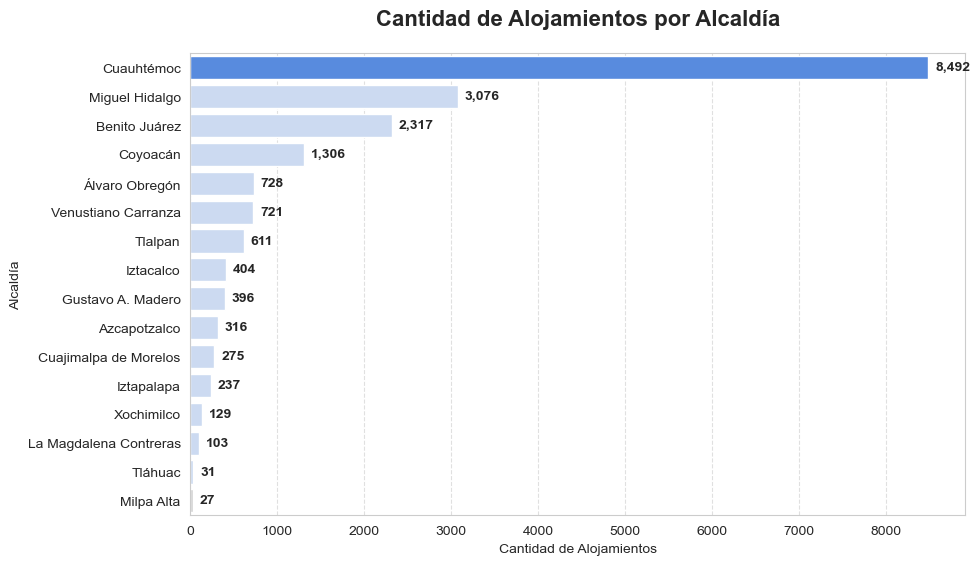

In [ ]:
# Realizar gráfico de barras
alojamientos_por_alcaldia = df_copy['neighbourhood'].value_counts()
plt.figure(figsize=(10, 6))
colors_alcaldia = ['#4285F4' if v == alojamientos_por_alcaldia.max() 
                   else '#D3D3D3' if v == alojamientos_por_alcaldia.min() 
                   else '#C6D9F7' 
                   for v in alojamientos_por_alcaldia]
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax1 = sns.barplot(x=alojamientos_por_alcaldia.values, y=alojamientos_por_alcaldia.index, palette=colors_alcaldia, hue=alojamientos_por_alcaldia.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad de Alojamientos por Alcaldía', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cantidad de Alojamientos')
plt.ylabel('Alcaldía')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


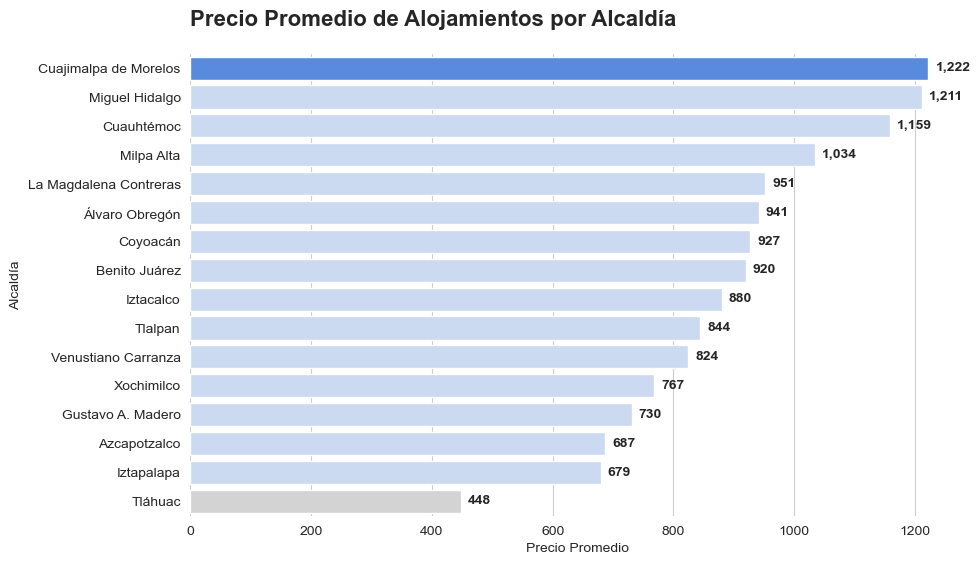

In [125]:
# Realizar gráfico de barras
#Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
mean_alcaldia = df_copy.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
colors_alcaldia = ['#4285F4' if v == mean_alcaldia.max() else '#D3D3D3' if v == mean_alcaldia.min() else '#C6D9F7' for v in mean_alcaldia]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=mean_alcaldia.values, y=mean_alcaldia.index, palette=colors_alcaldia, hue=mean_alcaldia.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Precio Promedio de Alojamientos por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Precio Promedio')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()

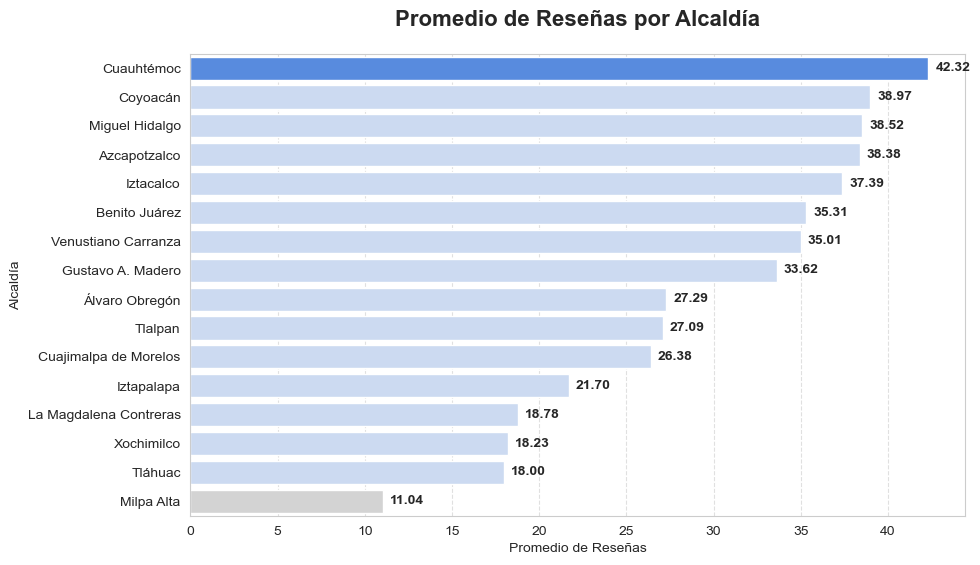

In [ ]:
# Realizar gráfico de barras
mean_reviews_alcaldia = df_copy.groupby('neighbourhood')['number_of_reviews'].mean().sort_values(ascending=False)
colors_reviews_alcaldia = ['#4285F4' if v == mean_reviews_alcaldia.max() else '#D3D3D3' if v == mean_reviews_alcaldia.min() else '#C6D9F7' for v in mean_reviews_alcaldia]


plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=mean_reviews_alcaldia.values, y=mean_reviews_alcaldia.index, palette=colors_reviews_alcaldia, hue=mean_reviews_alcaldia.index, legend=False)
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')
plt.title('Promedio de Reseñas por Alcaldía', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Promedio de Reseñas')
plt.ylabel('Alcaldía')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()